In [ ]:
# %%

# import package

import warnings
import sys
import csv
import os
import pandas as pd
from prophet import Prophet

sys.path.append('/home/gli/gli-data-science/akhiyar/lib/')
if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore" # Also affect subprocesses


import os
import ds_db
import helper_db
from helper_db import read_bq
from helper import transform_to_rupiah, rupiah_format

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

pd.options.display.float_format = '{:,.3f}'.format
import plotly.graph_objects as go
import string
from nltk.corpus import stopwords
from wordcloud import WordCloud,STOPWORDS
import re

from nlp_id.tokenizer import Tokenizer 
tokenizer = Tokenizer()

from nlp_id.lemmatizer import Lemmatizer 
lemmatizer = Lemmatizer() 

### get list of stopword
from nlp_id.stopword import StopWord 
stopword = StopWord() 
li_stopword = stopword.get_stopword() 

sw_eng = stopwords.words("indonesian") + list(string.punctuation) + li_stopword


#from mlxtend.frequent_patterns import apriori, association_rules#
#import rarfile

In [ ]:
#%%

# function untuk time series

def plot(data, kolom, kolom_date, tanggal):
    from datetime import datetime
    from datetime import datetime, timedelta

    date_base = datetime.strptime(tanggal, '%Y-%m-%d').date()
    # Maju 3 hari
    maju_3_hari = date_base + timedelta(days=3)
    # Mundur 3 hari
    mundur_3_hari = date_base - timedelta(days=3)

    months = pd.DataFrame(pd.date_range(start=mundur_3_hari, end=maju_3_hari, freq='d'), columns=['ds'])

    pred = data.reset_index().rename(columns={f'{kolom_date}': 'ds', f'{kolom}': 'y'})


    # Inisialisasi model Prophet
    model = Prophet()
    model.add_country_holidays(country_name='ID')
    # print(data)

    # Melatih model
    model.fit(pred.reset_index())
    forecast = model.predict(months)

    # Menambahkan hasil prediksi ke dalam DataFrame utama
    forecast.rename(columns={'ds': 'bulan', 'yhat': 'pred', 'yhat_lower':'bottom pred', 'yhat_upper':'upper pred'}, inplace=True)

    forecast = forecast[['bulan','bottom pred', 'upper pred', 'pred']]
    return forecast

In [ ]:
# %%

# import data

base_real = pd.read_excel('/home/gli/gli-data-science/Frans/model/dataset1.xlsx', sheet_name='OKT-NOV')
base_real['full_date'] = "24" + base_real['BULAN'].astype('str') + base_real['TANGGAL'].astype('str')
base_real['full_date'] =  pd.to_datetime(base_real['full_date'], format='%y%m%d')
base_real

,TANGGAL,BULAN,KODE_TOKO,JUMLAH_STRUK_SHIFT_PAGI,PERCENT_ONTIME_SHIFT_PAGI,AVG_SLA_SHIFT_PAGI,QTY_PER_STRUK_SHIFT_PAGI,SALES_SHIFT_PAGI,JUMLAH_STRUK_SHIFT_SIANG,PERCENT_ONTIME_SHIFT_SIANG,AVG_SLA_SHIFT_SIANG,QTY_PER_STRUK_SHIFT_SIANG,SALES_SHIFT_SIANG,KURIR_PAGI,KURIR_SIANG,full_date
0,1,10,1M6U,142,0.204,124.204,7.563,"15,144,114.560",148,0.365,79.306,6.612,"13,628,765.740",3,6,2024-10-01
1,1,10,1M6V,166,0.163,138.476,10.988,"21,941,389.670",160,0.287,107.974,9.338,"16,598,755.790",3,4,2024-10-01
2,1,10,JD75,187,0.289,90.984,8.027,"23,167,740.650",132,0.462,65.287,7.070,"12,373,117.150",5,4,2024-10-01
3,1,10,JD76,92,1.000,29.174,10.707,"13,081,894.560",68,0.971,31.448,11.567,"8,977,878.370",4,4,2024-10-01
4,1,10,KF18,143,0.650,53.154,11.245,"16,707,311.540",161,0.354,75.117,7.182,"11,379,151.400",2,4,2024-10-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
807,31,10,TI12,143,0.119,195.476,8.601,"15,365,619.890",132,0.114,183.078,8.884,"12,882,834.210",5,6,2024-10-31
808,31,10,TI17,233,0.206,144.871,8.940,"21,441,707.310",179,0.341,94.667,7.276,"13,455,720.620",6,5,2024-10-31
809,31,10,UD92,159,0.151,139.767,8.793,"16,802,278.110",125,0.184,111.154,9.094,"11,546,145.030",4,4,2024-10-31
810,31,10,UE21,107,1.000,26.907,8.906,"9,476,654.900",177,0.994,22.722,6.210,"12,102,683.840",5,4,2024-10-31


In [ ]:
# %%

# import tambahan data (nambahin distance tiap trip, duration tiap trip, dan rata pengiriman tiap trip)

distance = pd.read_parquet('/home/gli/gli-data-science/Frans/model/distance_per_trip.parquet')

base = pd.merge(base_real, distance, left_on=['TANGGAL', 'BULAN', 'KODE_TOKO'], right_on=['TANGGAL', 'BULAN', 'KODE_TOKO'])
base

,TANGGAL,BULAN,KODE_TOKO,JUMLAH_STRUK_SHIFT_PAGI,PERCENT_ONTIME_SHIFT_PAGI,AVG_SLA_SHIFT_PAGI,QTY_PER_STRUK_SHIFT_PAGI,SALES_SHIFT_PAGI,JUMLAH_STRUK_SHIFT_SIANG,PERCENT_ONTIME_SHIFT_SIANG,...,SALES_SHIFT_SIANG,KURIR_PAGI,KURIR_SIANG,full_date,DISTANCE_PER_TRIP_PAGI,DISTANCE_PER_TRIP_SIANG,DURATION_PER_TRIP_PAGI,DURATION_PER_TRIP_SIANG,DELIVERY_PER_TRIP_PAGI,DELIVERY_PER_TRIP_SIANG
0,1,10,TH72,142,0.542,55.113,10.866,"18,553,426.290",106,0.472,...,"10,376,547.710",4,3,2024-10-01,9.271,14.977,15.223,27.548,3.317,6.125
1,1,10,TI12,144,0.056,201.465,8.479,"17,923,181.930",137,0.241,...,"11,514,379.350",6,4,2024-10-01,9.918,12.385,17.637,23.031,3.964,4.933
2,1,11,1M6U,132,0.288,96.311,7.545,"17,230,859.610",134,0.537,...,"16,166,939.870",6,5,2024-11-01,7.997,11.509,12.690,19.430,2.905,4.433
3,1,11,1M6V,164,0.299,101.360,8.963,"21,164,141.840",152,0.316,...,"16,733,521.510",7,6,2024-11-01,11.544,14.859,21.893,29.000,4.405,6.043
4,1,11,JD75,200,0.510,63.540,8.535,"20,994,825.450",147,0.490,...,"15,027,611.130",5,4,2024-11-01,11.583,11.389,18.309,18.523,4.104,4.028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,31,10,TI12,143,0.119,195.476,8.601,"15,365,619.890",132,0.114,...,"12,882,834.210",5,6,2024-10-31,12.774,13.358,24.728,31.146,5.360,6.905
748,31,10,TI17,233,0.206,144.871,8.940,"21,441,707.310",179,0.341,...,"13,455,720.620",6,5,2024-10-31,13.602,13.442,23.276,24.107,4.533,4.683
749,31,10,UD92,159,0.151,139.767,8.793,"16,802,278.110",125,0.184,...,"11,546,145.030",4,4,2024-10-31,18.956,16.654,35.992,31.650,5.767,5.238
750,31,10,UE21,107,1.000,26.907,8.906,"9,476,654.900",177,0.994,...,"12,102,683.840",5,4,2024-10-31,8.625,7.482,11.925,11.034,2.500,3.689


In [ ]:
# %%

# coba cek hasil datanya
base[base['KODE_TOKO'] == '1M6U'].sort_values(by=['BULAN', 'TANGGAL']).head(30)

,TANGGAL,BULAN,KODE_TOKO,JUMLAH_STRUK_SHIFT_PAGI,PERCENT_ONTIME_SHIFT_PAGI,AVG_SLA_SHIFT_PAGI,QTY_PER_STRUK_SHIFT_PAGI,SALES_SHIFT_PAGI,JUMLAH_STRUK_SHIFT_SIANG,PERCENT_ONTIME_SHIFT_SIANG,...,SALES_SHIFT_SIANG,KURIR_PAGI,KURIR_SIANG,full_date,DISTANCE_PER_TRIP_PAGI,DISTANCE_PER_TRIP_SIANG,DURATION_PER_TRIP_PAGI,DURATION_PER_TRIP_SIANG,DELIVERY_PER_TRIP_PAGI,DELIVERY_PER_TRIP_SIANG
110,7,10,1M6U,114,0.333,102.263,8.553,"14,017,701.050",116,0.578,...,"10,778,114.470",2,6,2024-10-07,NaN,10.590,NaN,18.532,NaN,2.000
136,8,10,1M6U,112,0.482,70.000,6.295,"10,882,341.450",103,1.000,...,"9,681,593.740",4,5,2024-10-08,10.211,9.346,16.045,17.236,3.500,3.548
164,9,10,1M6U,116,0.362,77.612,6.078,"10,794,298.370",127,0.409,...,"12,883,703.780",4,4,2024-10-09,8.832,10.938,14.243,17.505,2.889,3.912
192,10,10,1M6U,136,0.338,100.765,5.831,"11,063,636.160",119,0.471,...,"10,240,687.430",3,4,2024-10-10,10.267,12.179,18.651,20.146,4.741,5.500
220,11,10,1M6U,127,0.370,91.528,7.205,"13,315,355.910",99,0.455,...,"8,310,905.440",4,4,2024-10-11,7.338,10.549,11.360,17.808,2.489,4.222
248,12,10,1M6U,169,0.213,136.249,7.402,"16,169,250.430",92,0.413,...,"6,784,486.710",4,4,2024-10-12,10.577,12.514,18.060,21.436,4.424,5.167
276,13,10,1M6U,145,0.331,99.972,8.090,"13,312,438.730",105,0.286,...,"10,378,766.760",3,5,2024-10-13,10.219,14.652,17.277,24.823,4.258,5.526
304,14,10,1M6U,125,0.528,56.392,6.240,"11,894,216.210",112,0.438,...,"10,703,046.730",5,5,2024-10-14,8.849,10.227,13.331,16.615,3.216,3.931
332,15,10,1M6U,142,0.373,77.676,7.465,"12,812,320.680",121,0.926,...,"10,979,952.020",5,3,2024-10-15,11.496,11.055,18.356,18.865,4.125,4.846
360,16,10,1M6U,124,0.661,63.121,8.177,"13,708,037.970",125,0.520,...,"11,817,161.390",3,5,2024-10-16,9.635,10.760,15.762,18.013,3.656,3.812


In [ ]:
# %%

# encode kode toko
df = base.copy()

unique_categories = df['KODE_TOKO'].unique()  # Ambil nilai unik
sorted_categories = sorted(unique_categories)  # Urutkan nilai unik

# Buat mapping berdasarkan urutan yang sudah di-sort
category_mapping = {category: index + 1 for index, category in enumerate(sorted_categories)}
print(category_mapping)
df['KODE_TOKO'] = df['KODE_TOKO'].map(category_mapping)
df

{'1M6U': 1, '1M6V': 2, 'JD75': 3, 'JD76': 4, 'KF18': 5, 'KF65': 6, 'PA39': 7, 'TH06': 8, 'TH72': 9, 'TI12': 10, 'TI17': 11, 'UD92': 12, 'UE21': 13, 'W785': 14}


,TANGGAL,BULAN,KODE_TOKO,JUMLAH_STRUK_SHIFT_PAGI,PERCENT_ONTIME_SHIFT_PAGI,AVG_SLA_SHIFT_PAGI,QTY_PER_STRUK_SHIFT_PAGI,SALES_SHIFT_PAGI,JUMLAH_STRUK_SHIFT_SIANG,PERCENT_ONTIME_SHIFT_SIANG,...,SALES_SHIFT_SIANG,KURIR_PAGI,KURIR_SIANG,full_date,DISTANCE_PER_TRIP_PAGI,DISTANCE_PER_TRIP_SIANG,DURATION_PER_TRIP_PAGI,DURATION_PER_TRIP_SIANG,DELIVERY_PER_TRIP_PAGI,DELIVERY_PER_TRIP_SIANG
0,1,10,9,142,0.542,55.113,10.866,"18,553,426.290",106,0.472,...,"10,376,547.710",4,3,2024-10-01,9.271,14.977,15.223,27.548,3.317,6.125
1,1,10,10,144,0.056,201.465,8.479,"17,923,181.930",137,0.241,...,"11,514,379.350",6,4,2024-10-01,9.918,12.385,17.637,23.031,3.964,4.933
2,1,11,1,132,0.288,96.311,7.545,"17,230,859.610",134,0.537,...,"16,166,939.870",6,5,2024-11-01,7.997,11.509,12.690,19.430,2.905,4.433
3,1,11,2,164,0.299,101.360,8.963,"21,164,141.840",152,0.316,...,"16,733,521.510",7,6,2024-11-01,11.544,14.859,21.893,29.000,4.405,6.043
4,1,11,3,200,0.510,63.540,8.535,"20,994,825.450",147,0.490,...,"15,027,611.130",5,4,2024-11-01,11.583,11.389,18.309,18.523,4.104,4.028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,31,10,10,143,0.119,195.476,8.601,"15,365,619.890",132,0.114,...,"12,882,834.210",5,6,2024-10-31,12.774,13.358,24.728,31.146,5.360,6.905
748,31,10,11,233,0.206,144.871,8.940,"21,441,707.310",179,0.341,...,"13,455,720.620",6,5,2024-10-31,13.602,13.442,23.276,24.107,4.533,4.683
749,31,10,12,159,0.151,139.767,8.793,"16,802,278.110",125,0.184,...,"11,546,145.030",4,4,2024-10-31,18.956,16.654,35.992,31.650,5.767,5.238
750,31,10,13,107,1.000,26.907,8.906,"9,476,654.900",177,0.994,...,"12,102,683.840",5,4,2024-10-31,8.625,7.482,11.925,11.034,2.500,3.689


In [ ]:
# %%

df.columns

Index(['TANGGAL', 'BULAN', 'KODE_TOKO', 'JUMLAH_STRUK_SHIFT_PAGI',
       'PERCENT_ONTIME_SHIFT_PAGI', 'AVG_SLA_SHIFT_PAGI',
       'QTY_PER_STRUK_SHIFT_PAGI', 'SALES_SHIFT_PAGI',
       'JUMLAH_STRUK_SHIFT_SIANG', 'PERCENT_ONTIME_SHIFT_SIANG',
       'AVG_SLA_SHIFT_SIANG', 'QTY_PER_STRUK_SHIFT_SIANG', 'SALES_SHIFT_SIANG',
       'KURIR_PAGI', 'KURIR_SIANG', 'full_date', 'DISTANCE_PER_TRIP_PAGI',
       'DISTANCE_PER_TRIP_SIANG', 'DURATION_PER_TRIP_PAGI',
       'DURATION_PER_TRIP_SIANG', 'DELIVERY_PER_TRIP_PAGI',
       'DELIVERY_PER_TRIP_SIANG'],
      dtype='object')

In [ ]:
# %%

# pilihin kolom buat jd fitur

df['KURIR_ALL'] = df['KURIR_PAGI'] + df['KURIR_SIANG']
df = df[[
    'TANGGAL', 'BULAN', 'KODE_TOKO', 'JUMLAH_STRUK_SHIFT_PAGI',
    'PERCENT_ONTIME_SHIFT_PAGI', 'AVG_SLA_SHIFT_PAGI',
    'QTY_PER_STRUK_SHIFT_PAGI', 'SALES_SHIFT_PAGI',
    'KURIR_PAGI','KURIR_ALL', 'DISTANCE_PER_TRIP_PAGI', 'DURATION_PER_TRIP_PAGI', 'DELIVERY_PER_TRIP_PAGI'
]]

df.columns = [
    'T', 'B', 'STORE', 'STRUK_P',
    'ONTIME_P', 'SLA_P',
    'QTY_P', 'SALES_P',
    'KURIR_P','KURIR_ALL', 'DISTANCE_T_P', 'DURATION_T_P', 'DELIVERY_T_P'
]

In [ ]:
# %%

# train test split

X = df.drop(columns=['ONTIME_P','SLA_P', 'KURIR_ALL'])
y = df[['SLA_P']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
print(len(X_train), len(X_test))
X_train.columns

503 249


Index(['T', 'B', 'STORE', 'STRUK_P', 'QTY_P', 'SALES_P', 'KURIR_P',
       'DISTANCE_T_P', 'DURATION_T_P', 'DELIVERY_T_P'],
      dtype='object')

In [ ]:
# %%

# train

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

reg = XGBRegressor(random_state=42).fit(X_train, y_train)
print("train :",reg.score(X_train, y_train))
print("test ",reg.score(X_test, y_test))

train : 0.99998533682474
test  0.6555951503610704


In [ ]:
# %%

print(X_train.columns)

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')  # Tingkatkan resolusi plot

Index(['T', 'B', 'STORE', 'STRUK_P', 'QTY_P', 'SALES_P', 'KURIR_P',
       'DISTANCE_T_P', 'DURATION_T_P', 'DELIVERY_T_P'],
      dtype='object')


In [ ]:
# %%

# function usulan kurir

def usulan_kurir(kode_toko_input, tanggal, bulan, ontime=1, avg_sla=60):
    kode_toko = category_mapping[kode_toko_input]

    pred_struk = round(plot(base[base['KODE_TOKO'] == kode_toko_input],'JUMLAH_STRUK_SHIFT_PAGI', 'full_date', f'2024-{bulan}-{tanggal}')['pred'].mean())
    pred_qty = round(plot(base[base['KODE_TOKO'] == kode_toko_input],'QTY_PER_STRUK_SHIFT_PAGI', 'full_date', f'2024-{bulan}-{tanggal}')['pred'].mean())
    pred_sales = round(plot(base[base['KODE_TOKO'] == kode_toko_input],'SALES_SHIFT_PAGI', 'full_date', f'2024-{bulan}-{tanggal}')['pred'].mean())
    pred_sales = round(plot(base[base['KODE_TOKO'] == kode_toko_input],'SALES_SHIFT_PAGI', 'full_date', f'2024-{bulan}-{tanggal}')['pred'].mean())
    pred_kurir = round(plot(base[base['KODE_TOKO'] == kode_toko_input],'KURIR_PAGI', 'full_date', f'2024-{bulan}-{tanggal}')['pred'].mean())

    import math
    data_pred = pd.DataFrame({
        'T':[tanggal]*20,
        'B':[bulan]*20,
        'STORE':[kode_toko]*20,
        'STRUK_P':[pred_struk]*20,
        'QTY_P':[pred_qty]*20,
        'SALES_P': [pred_sales]*20,
        'KURIR_P':range(pred_kurir, pred_kurir + 20),
        'DISTANCE_T_P':[round(df[df['STORE']==kode_toko].sort_values(by=['B', 'T'], ascending=[False, False]).head(30)['DISTANCE_T_P'].mean())]*20,
        'DURATION_T_P':[round(df[df['STORE']==kode_toko].sort_values(by=['B', 'T'], ascending=[False, False]).head(30)['DURATION_T_P'].mean())]*20,
        'DELIVERY_T_P':[round(df[df['STORE']==kode_toko].sort_values(by=['B', 'T'], ascending=[False, False]).head(30)['DELIVERY_T_P'].mean())]*20,
    })

    
    usulan_kurir_pagi = reg.predict(data_pred)

    kurir_list = []

    for couriers, predicted_time in zip(data_pred['KURIR_P'], usulan_kurir_pagi):
        kurir_list.append({'courier': couriers, 'predicted_time': predicted_time})
    print(kurir_list)

    kurir_df = pd.DataFrame(kurir_list)
    kurir_pagi = kurir_df[kurir_df['predicted_time'] == kurir_df['predicted_time'].min()]['courier'].min() 

    usulan_kurir_siang = round(df[df['STORE']==kode_toko].sort_values(by=['B', 'T'], ascending=[False, False]).head(30)['KURIR_ALL'].mean()) - kurir_pagi
    
    print('Usulan Kurir Pagi real\t\t:', kurir_pagi)
    print('Usulan Kurir Siang real\t\t:', df[df['STORE']==kode_toko].sort_values(by=['B', 'T'], ascending=[False, False]).head(30)['KURIR_ALL'].mean() - kurir_pagi)

    print('Usulan Kurir Pagi\t\t:', kurir_pagi)
    print('Usulan Kurir Siang\t\t:', usulan_kurir_siang)

    print('rata-rata prediksi struk\t:',pred_struk)
    print('rata-rata prediksi qty\t\t:',pred_qty)
    print('rata-rata prediksi sales\t:',pred_sales)
    print('rata-rata prediksi sla\t\t:',kurir_df[kurir_df['courier'] == kurir_pagi]['predicted_time'].values[0])

    return kurir_pagi, usulan_kurir_siang, data_pred, kurir_df

In [ ]:
# %%

# coba function usulan kurir

input_toko_pred = '1M6V'
pagi, siang, data_pred, kurir_df = usulan_kurir(kode_toko_input=input_toko_pred, tanggal=11, bulan=11)

15:07:09 - cmdstanpy - INFO - Chain [1] start processing
15:07:10 - cmdstanpy - INFO - Chain [1] done processing
15:07:10 - cmdstanpy - INFO - Chain [1] start processing
15:07:10 - cmdstanpy - INFO - Chain [1] done processing
15:07:10 - cmdstanpy - INFO - Chain [1] start processing
15:07:11 - cmdstanpy - INFO - Chain [1] done processing
15:07:11 - cmdstanpy - INFO - Chain [1] start processing
15:07:11 - cmdstanpy - INFO - Chain [1] done processing
15:07:12 - cmdstanpy - INFO - Chain [1] start processing
15:07:12 - cmdstanpy - INFO - Chain [1] done processing


[{'courier': 6, 'predicted_time': 52.35242}, {'courier': 7, 'predicted_time': 51.104496}, {'courier': 8, 'predicted_time': 51.104496}, {'courier': 9, 'predicted_time': 51.104496}, {'courier': 10, 'predicted_time': 51.104496}, {'courier': 11, 'predicted_time': 51.104496}, {'courier': 12, 'predicted_time': 51.104496}, {'courier': 13, 'predicted_time': 51.104496}, {'courier': 14, 'predicted_time': 51.104496}, {'courier': 15, 'predicted_time': 51.104496}, {'courier': 16, 'predicted_time': 51.104496}, {'courier': 17, 'predicted_time': 51.104496}, {'courier': 18, 'predicted_time': 51.104496}, {'courier': 19, 'predicted_time': 51.104496}, {'courier': 20, 'predicted_time': 51.104496}, {'courier': 21, 'predicted_time': 51.104496}, {'courier': 22, 'predicted_time': 51.104496}, {'courier': 23, 'predicted_time': 51.104496}, {'courier': 24, 'predicted_time': 51.104496}, {'courier': 25, 'predicted_time': 51.104496}]
Usulan Kurir Pagi real		: 7
Usulan Kurir Siang real		: 5.433333333333334
Usulan Kuri

In [ ]:
# %%

# check n re check
test = df[df['STORE']==category_mapping[input_toko_pred]].sort_values(by=['B', 'T'], ascending=[False, False]).head(30)
print('rata2 ontime rate: ',test[test['KURIR_ALL'] >= pagi + siang]['ONTIME_P'].mean(),
      '\nrata2 sales: ', test[test['KURIR_ALL'] >= pagi + siang]['SALES_P'].mean(),
      '\nrata2 sla: ', test[test['KURIR_ALL'] >= pagi + siang]['SLA_P'].mean(),
      )
test[test['KURIR_ALL'] >= pagi + siang]

rata2 ontime rate:  0.5239444444444444 
rata2 sales:  15886853.048888888 
rata2 sla:  73.3869812274074


,T,B,STORE,STRUK_P,ONTIME_P,SLA_P,QTY_P,SALES_P,KURIR_P,KURIR_ALL,DISTANCE_T_P,DURATION_T_P,DELIVERY_T_P
697,28,11,2,151,0.192,124.841,8.642,"18,671,655.810",7,13,13.069,24.523,4.742
655,26,11,2,160,0.713,44.781,11.113,"23,749,103.420",7,13,9.709,18.157,3.096
627,25,11,2,158,0.722,46.823,9.848,"19,884,523.270",7,13,10.929,20.700,3.500
599,24,11,2,179,0.615,60.307,7.447,"21,225,050.450",7,13,10.970,20.890,3.850
571,23,11,2,134,0.731,41.731,10.425,"13,652,066.490",7,13,10.870,20.915,3.730
543,22,11,2,127,0.661,50.874,9.512,"15,019,829.580",7,13,8.813,16.608,3.049
515,21,11,2,127,0.661,46.000,6.787,"12,028,178.440",7,13,11.213,22.185,4.161
487,20,11,2,136,0.801,43.956,8.066,"14,417,702.730",7,13,8.746,17.125,3.091
459,19,11,2,143,0.517,74.056,6.846,"13,737,945.860",7,13,8.802,18.133,3.500
431,18,11,2,156,0.487,63.596,6.641,"14,389,563.110",7,13,11.775,23.378,4.438


In [ ]:
# %%

# feature importance

importance = reg.get_booster().get_score(importance_type='gain')
print(importance)

{'T': 232.48191833496094, 'B': 683.422607421875, 'STORE': 1037.869873046875, 'STRUK_P': 216.2832489013672, 'QTY_P': 105.89987182617188, 'SALES_P': 184.82850646972656, 'KURIR_P': 89.51766204833984, 'DISTANCE_T_P': 311.5732727050781, 'DURATION_T_P': 173.14486694335938, 'DELIVERY_T_P': 1608.9376220703125}


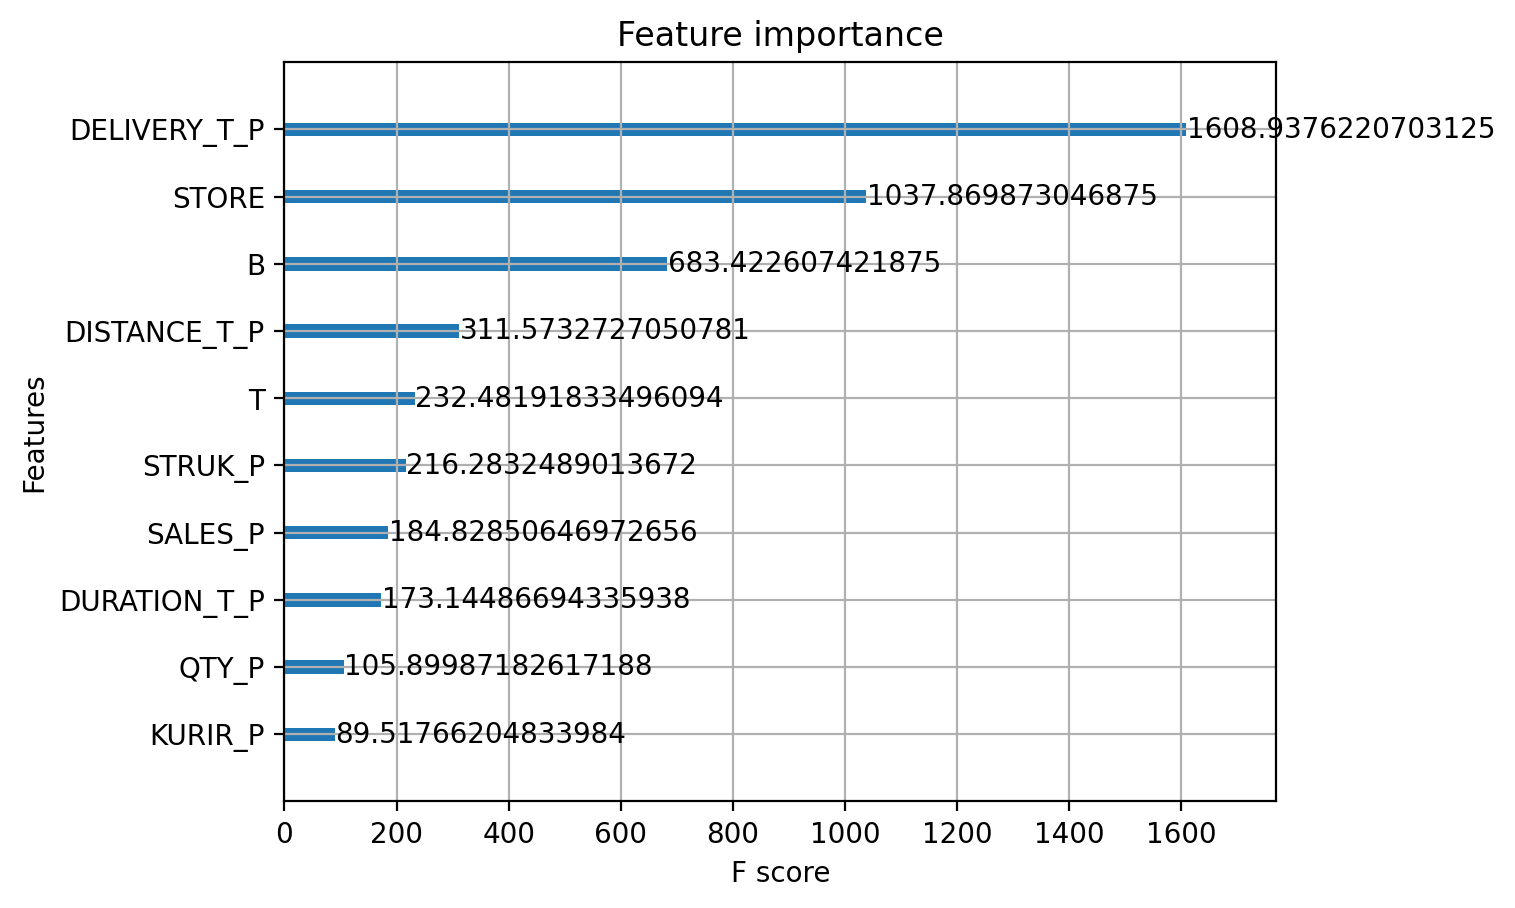

In [ ]:
# %%

from xgboost import XGBClassifier, plot_importance
plot_importance(reg, importance_type='gain')  # 'gain', 'weight', 'cover'
plt.show()